# MC-Match
### MC-Match helps the user to find a motorcycle that fits their needs and budget, as well as helping to predict the price on a motorcycle the user already owns. 
## EDA 

here we will evaluate the dataset and filter out the actual data we want to use

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [32]:
df = pd.read_csv('dataset/motorcycles_clean.csv')

In [33]:
df.head()

,Company,Country of Origin,Model,Number of cc,Horsepower,Torque,Transmission Type,Drivetrain,Number of Seating,Year,Looks,Body Type,Engine Type,Number of Cylinders,Price (SEK),Usage Type
0,Aprilia,Italy,RS 660,659.0,100.0,67.0,Manual,Chain,2,2021,Sport,Naked/Street,Parallel-twin,2.0,90000.0,Street
1,Aprilia,Italy,Tuono 660,659.0,100.0,67.0,Manual,Chain,2,2021,Sport,Naked/Street,Parallel-twin,2.0,82000.0,Street
2,Aprilia,Italy,RS 125,124.9,15.0,12.0,Manual,Chain,2,2022,Sport,Sport,Single-cylinder,1.0,44000.0,Race
3,Aprilia,Italy,Shiver 900,896.0,95.0,90.0,Manual,Shaft Drive,2,2022,Adventure,Naked/Street,V-twin,2.0,75000.0,Street
4,Aprilia,Italy,Tuono 1100,1077.0,175.0,121.0,Manual,Shaft Drive,2,2022,Adventure,Naked/Street,V-twin,2.0,132000.0,Street


In [34]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Company              357 non-null    str    
 1   Country of Origin    357 non-null    str    
 2   Model                357 non-null    str    
 3   Number of cc         357 non-null    float64
 4   Horsepower           357 non-null    float64
 5   Torque               357 non-null    float64
 6   Transmission Type    357 non-null    str    
 7   Drivetrain           357 non-null    str    
 8   Number of Seating    357 non-null    int64  
 9   Year                 357 non-null    int64  
 10  Looks                357 non-null    str    
 11  Body Type            357 non-null    str    
 12  Engine Type          357 non-null    str    
 13  Number of Cylinders  357 non-null    float64
 14  Price (SEK)          357 non-null    float64
 15  Usage Type           357 non-null    str    
dtypes

In [35]:
df.isnull().sum()

Company                0
Country of Origin      0
Model                  0
Number of cc           0
Horsepower             0
Torque                 0
Transmission Type      0
Drivetrain             0
Number of Seating      0
Year                   0
Looks                  0
Body Type              0
Engine Type            0
Number of Cylinders    0
Price (SEK)            0
Usage Type             0
dtype: int64

In [36]:
df.dropna(inplace=True)

In [37]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Company              357 non-null    str    
 1   Country of Origin    357 non-null    str    
 2   Model                357 non-null    str    
 3   Number of cc         357 non-null    float64
 4   Horsepower           357 non-null    float64
 5   Torque               357 non-null    float64
 6   Transmission Type    357 non-null    str    
 7   Drivetrain           357 non-null    str    
 8   Number of Seating    357 non-null    int64  
 9   Year                 357 non-null    int64  
 10  Looks                357 non-null    str    
 11  Body Type            357 non-null    str    
 12  Engine Type          357 non-null    str    
 13  Number of Cylinders  357 non-null    float64
 14  Price (SEK)          357 non-null    float64
 15  Usage Type           357 non-null    str    
dtypes

In [38]:
df.isnull().sum()

Company                0
Country of Origin      0
Model                  0
Number of cc           0
Horsepower             0
Torque                 0
Transmission Type      0
Drivetrain             0
Number of Seating      0
Year                   0
Looks                  0
Body Type              0
Engine Type            0
Number of Cylinders    0
Price (SEK)            0
Usage Type             0
dtype: int64

## Overview of numeric variables in the dataset

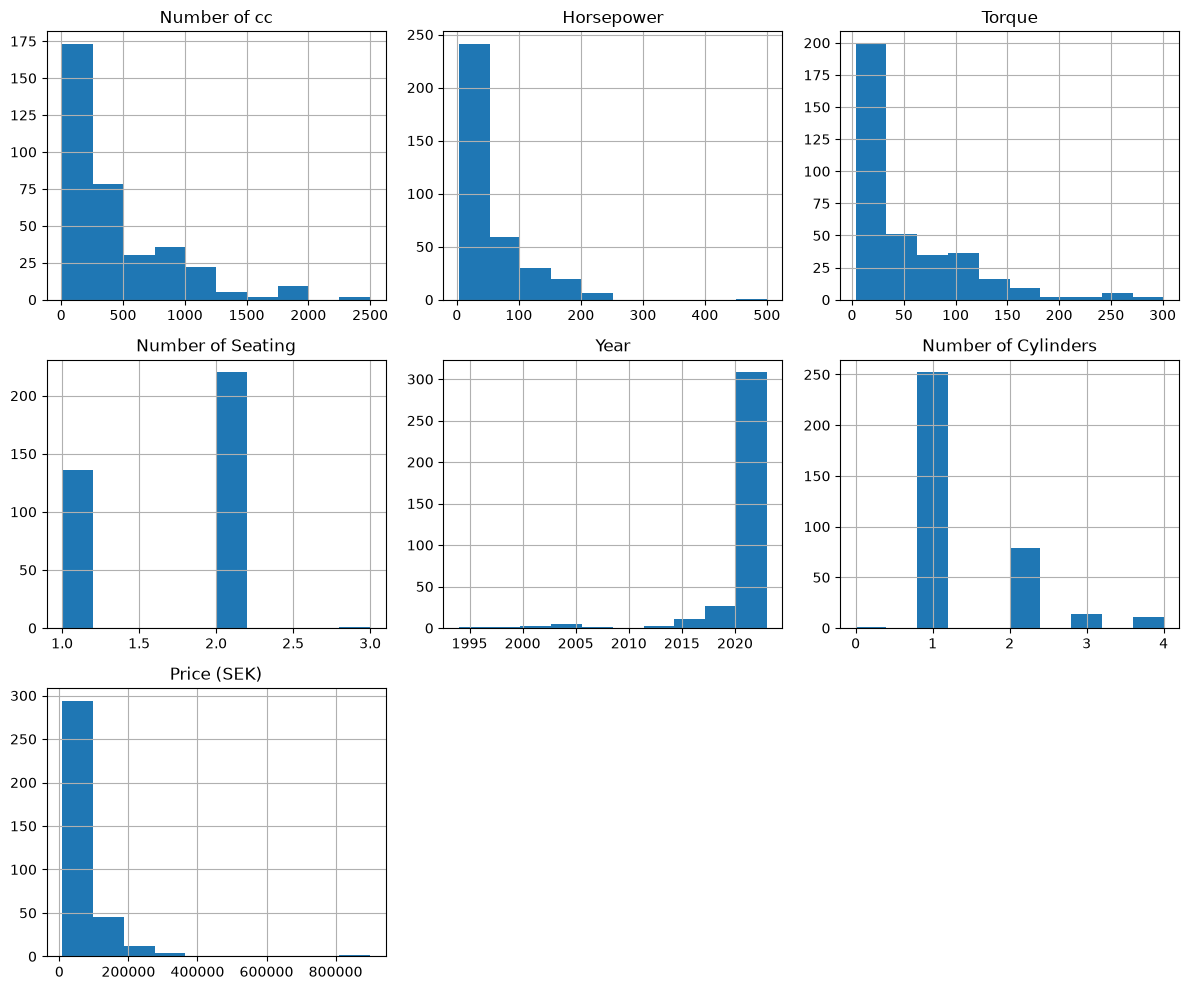

In [39]:
df.hist(figsize=(12, 10))
plt.tight_layout()
plt.show()

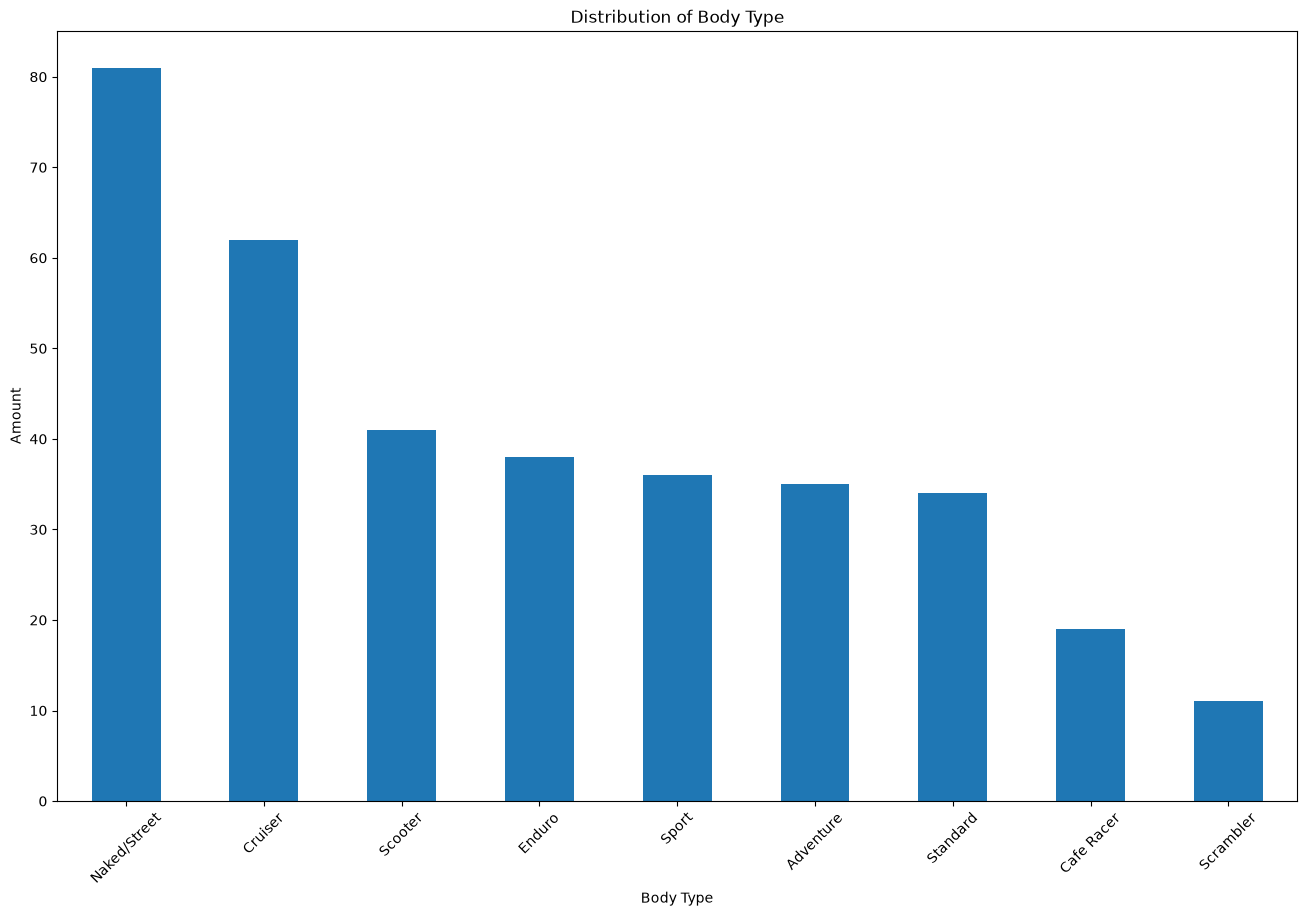

In [40]:
df['Body Type'].value_counts().plot(kind='bar', figsize=(16, 10))

plt.xlabel('Body Type')
plt.ylabel('Amount')
plt.title('Distribution of Body Type')
plt.xticks(rotation=45)
plt.show()


In [41]:
df['Body Type'].value_counts()


Body Type
Naked/Street    81
Cruiser         62
Scooter         41
Enduro          38
Sport           36
Adventure       35
Standard        34
Cafe Racer      19
Scrambler       11
Name: count, dtype: int64

===========================================================================================================================================
## Behind the curtens 
With help from the histogram we found some odd data in the dataset. 
- Some motorcycle had 900 cylinders which is impossible so we changed them to the correct amount. 
- We combined a lot of different body types into the bigger main groups that can be seen above. There were a lot of body type that represented the same type but with different names/casing. 
- The pricings was also in a differant value that we converted from INR to -> SEK. 
- We dropped the rows that had missing values. 

===========================================================================================================================================

## How's the price distrubuted in the dataset?


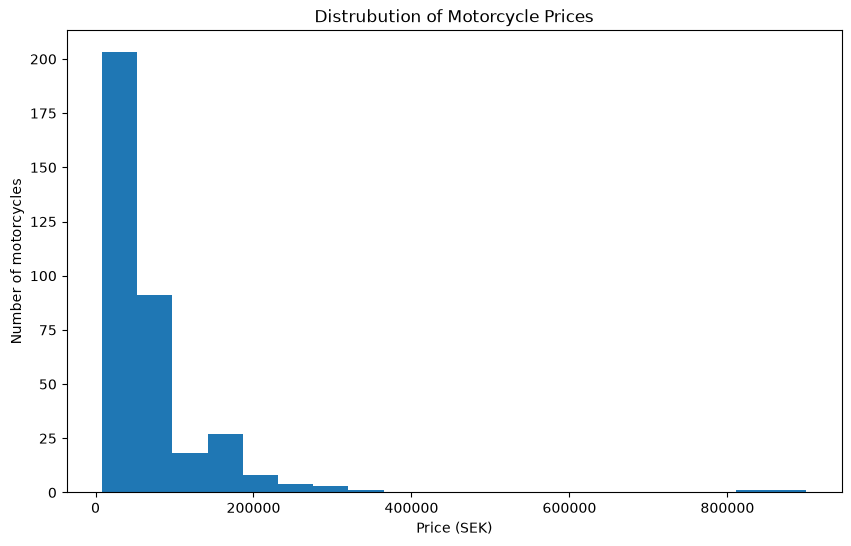

In [42]:
plt.figure(figsize=(10, 6))
plt.hist(df["Price (SEK)"], bins=20)

plt.xlabel("Price (SEK)")
plt.ylabel("Number of motorcycles")
plt.title("Distrubution of Motorcycle Prices")

plt.show()


/tmp/ipykernel_237961/1933241096.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df["Price (SEK)"], vert=False)


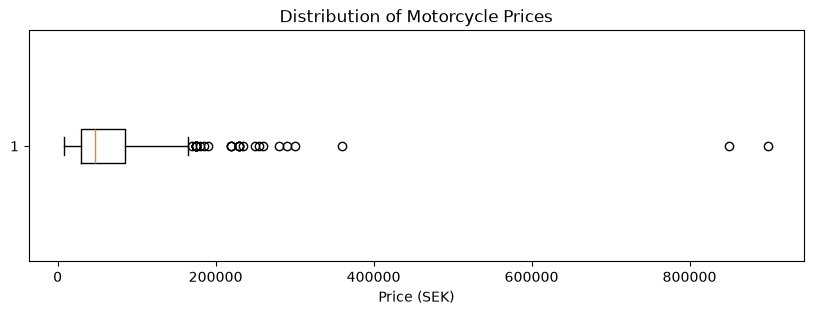

In [43]:
plt.figure(figsize=(10, 3))

plt.boxplot(df["Price (SEK)"], vert=False)

plt.xlabel("Price (SEK)")
plt.title("Distribution of Motorcycle Prices")

plt.show()

Most motorcycles are priced below 100,000 SEK. Most of the others are between 100,000 and 300,000 SEK, with a few around 400,000 SEK. There is also one motorcycle that stands out at around 900,000 SEK. Overall, the prices are mostly on the lower end, with a few much more expensive motorcycles.


## Price vs body type

<Figure size 1200x600 with 0 Axes>

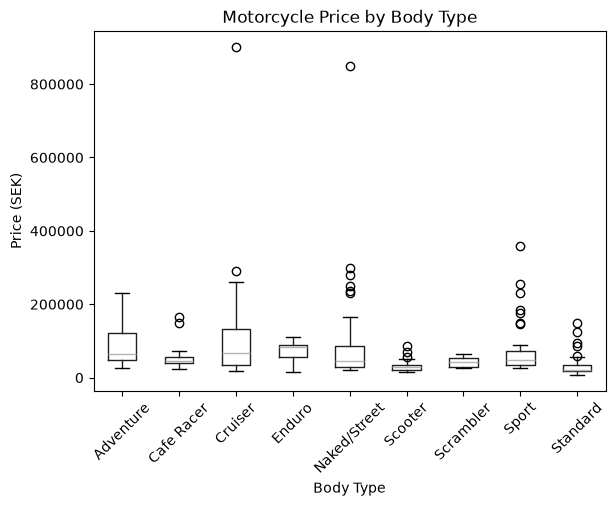

In [44]:
plt.figure(figsize=(12, 6))

df.boxplot(
    column="Price (SEK)",
    by="Body Type",
    grid=False
)

plt.xlabel("Body Type")
plt.ylabel("Price (SEK)")
plt.title("Motorcycle Price by Body Type")
plt.suptitle("")

plt.xticks(rotation=45)
plt.show()

Adventure and cruiser motorcycles generally have the highest prices, while scooters, cafe racers and scramblers are among the cheapest. Standard motorcycles have a relatively low median price but several expensive outliers. Sport and naked/street motorcycles also have some very high-priced outliers.


## 10 most expensive motorcycles in dataset

In [45]:
df.nlargest(10, "Price (SEK)")[["Company", "Model", "Price (SEK)"]]

,Company,Model,Price (SEK)
44,Confederate,Hellcat,900000.0
45,Confederate,Wraith,850000.0
124,Norton,V4SV,360000.0
354,Energica Motor Company,Eva Ribelle RS,299900.0
74,Indian,Challenger Dark Horse,290000.0
353,Energica Motor Company,EGO+,279900.0
352,Energica Motor Company,EsseEsse9,259900.0
19,BMW,S 1000 RR,255000.0
351,Energica Motor Company,Eva Ribelle,249900.0
117,MV Agusta,Brutale 1000 RR,235000.0


To get a better understanding of the highest-priced motorcycles in the dataset, we looked at the most expensive models and which companies they belong to. This also helps us identify which brands are positioned in the premium price range.


In [46]:
df.nlargest(10, "Horsepower")[["Company", "Model", "Price (SEK)", "Horsepower"]]

,Company,Model,Price (SEK),Horsepower
219,Triton Electric Bikes,Artemis,45000.0,500.0
220,Apollo,Artemis,25000.0,250.0
221,Hero Electric,Artemis,18000.0,250.0
222,Ampere,Artemis,15000.0,250.0
50,Ducati,Panigale V4,230000.0,221.0
117,MV Agusta,Brutale 1000 RR,235000.0,208.0
44,Confederate,Hellcat,900000.0,205.0
160,Yamaha,R1,185000.0,200.0
19,BMW,S 1000 RR,255000.0,199.0
81,Kawasaki,Z H2,165000.0,197.0


## Korrelation between price and the numeric valuables

Number of cc: 0.61


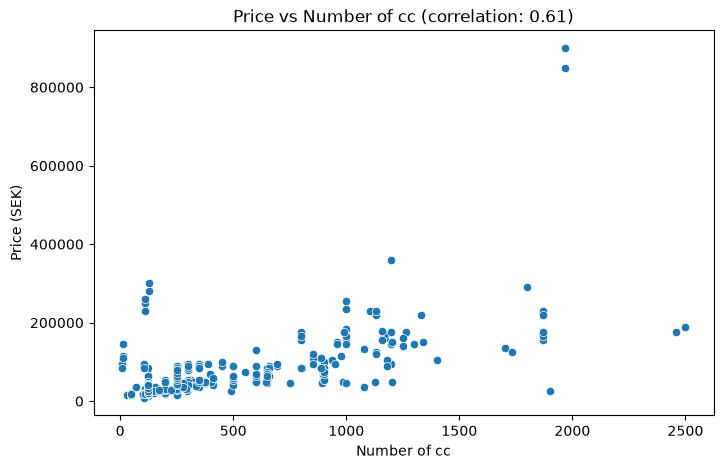

Horsepower: 0.60


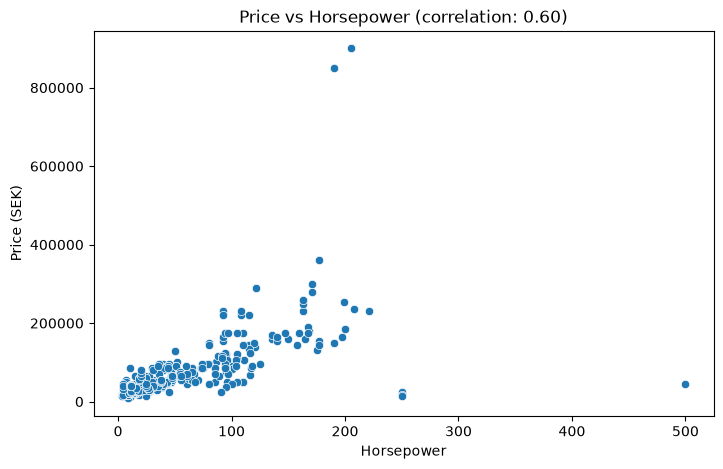

Torque: 0.65


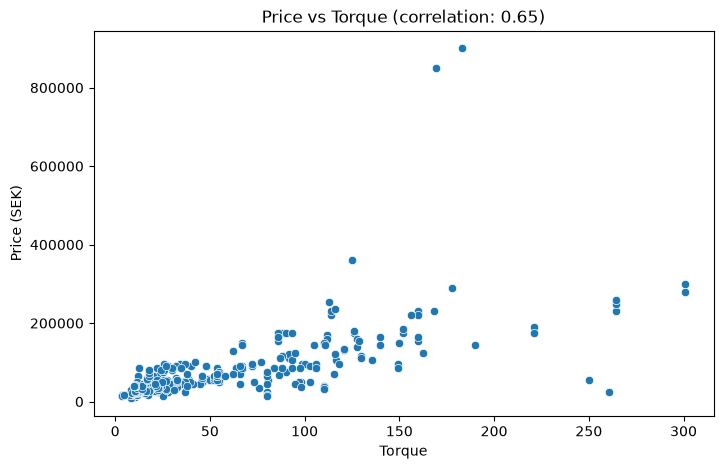

Year: 0.06


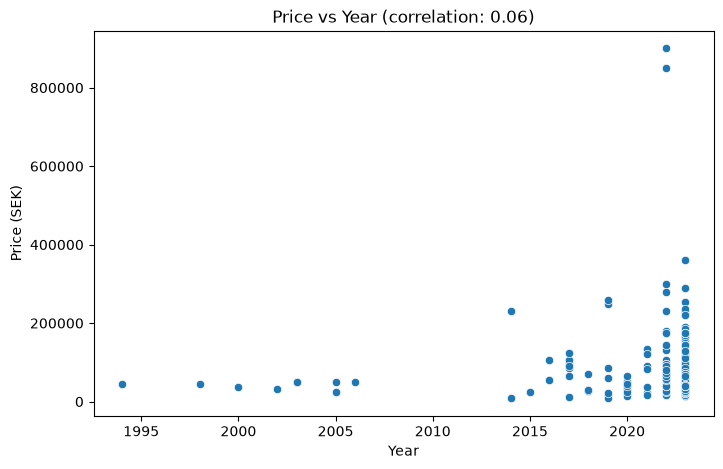

Number of Cylinders: 0.45


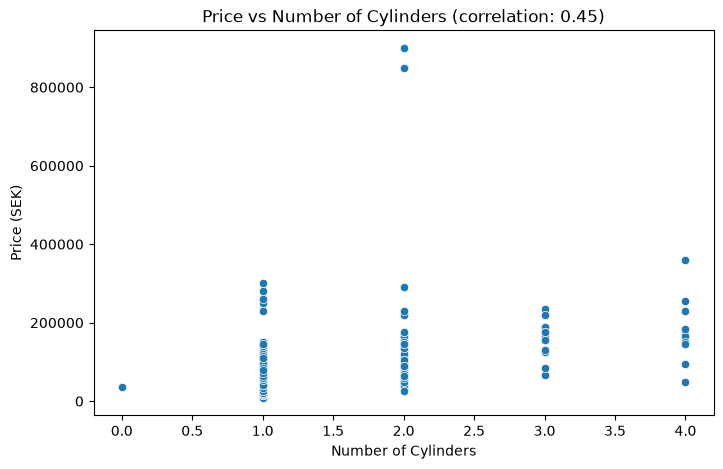

In [47]:
numeric_features = [
    "Number of cc",
    "Horsepower",
    "Torque",
    "Year",
    "Number of Cylinders"
]


for feature in numeric_features:
    correlation = df[feature].corr(df["Price (SEK)"])

    print(f"{feature}: {correlation:.2f}")

    plt.figure(figsize=(8, 5))
    sns.scatterplot(data=df, x=feature, y="Price (SEK)")
    plt.title(f"Price vs {feature} (correlation: {correlation:.2f})")
    plt.xlabel(feature)
    plt.ylabel("Price (SEK)")
    plt.show()

There seems to be a general relationship between engine size and price. Motorcycles with higher engine sizes are generally more expensive, although there is quite a lot of variation between motorcycles with similar engine sizes. There are also a few very expensive outliers.

## Correlation matrix, numeric values and price 

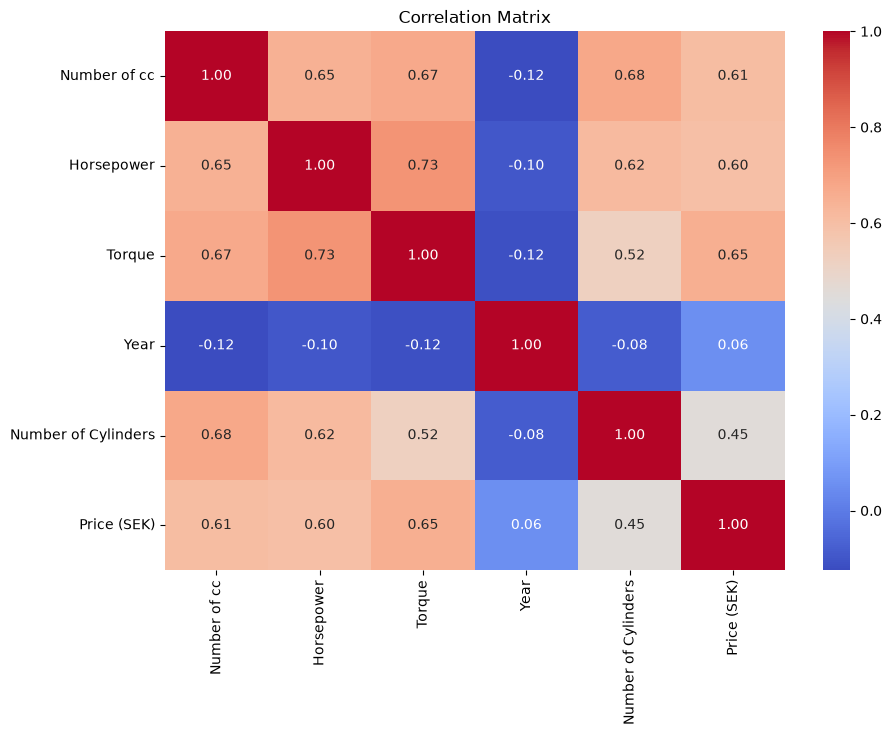

In [48]:
numeric_features_with_price = numeric_features + ["Price (SEK)"]

corr = df[numeric_features_with_price].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

## What defines a Body Type?
### Body type vs technical features

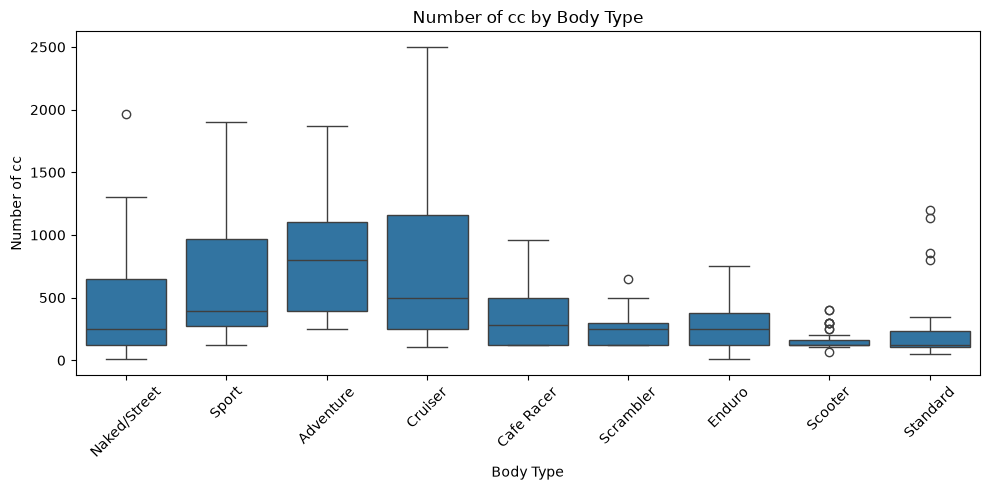

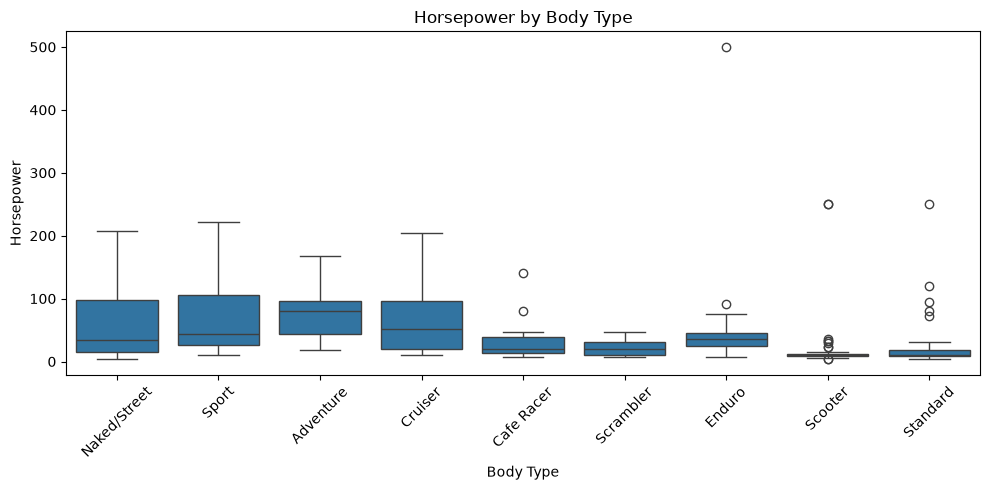

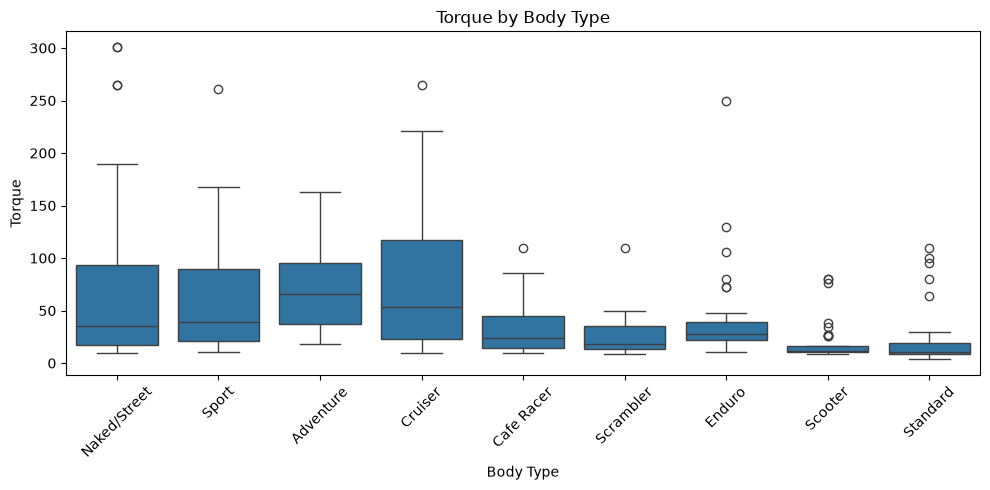

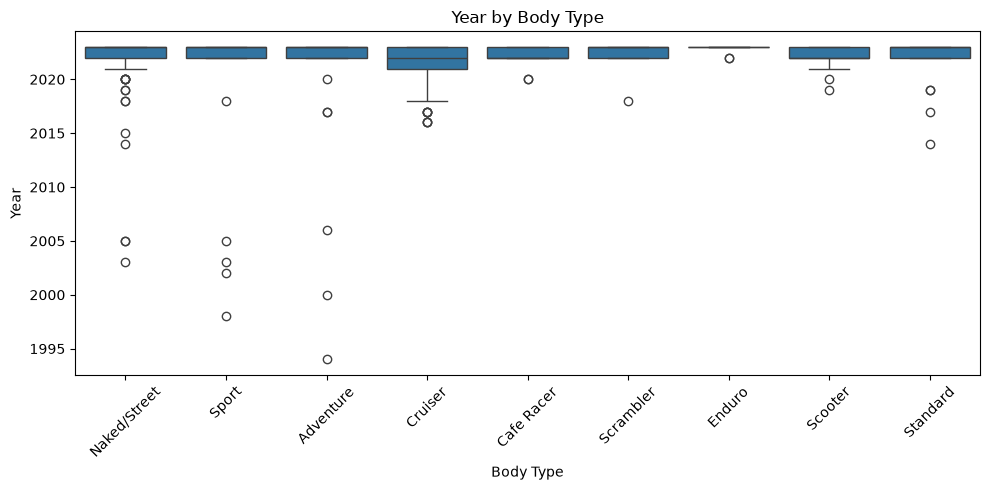

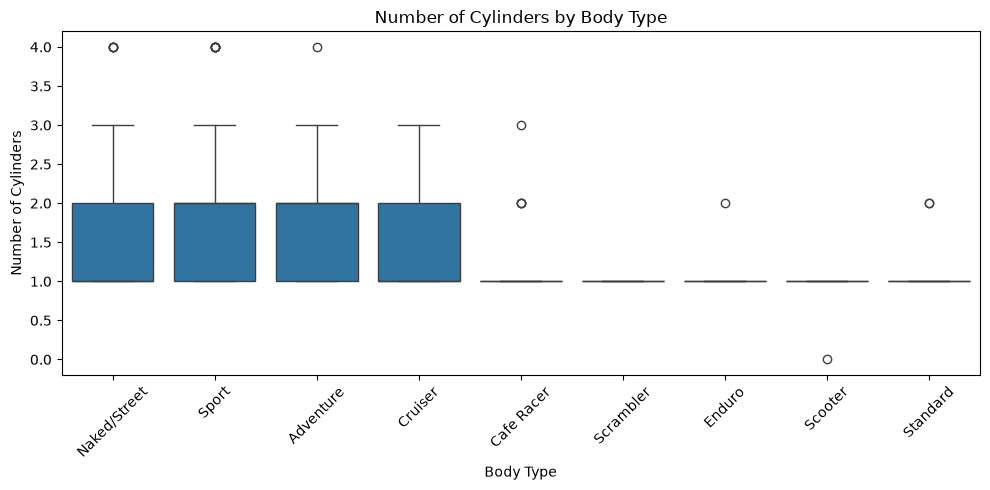

In [49]:
features = [
    "Number of cc",
    "Horsepower",
    "Torque",
    "Year",
    "Number of Cylinders"
]

for feature in features:
    plt.figure(figsize=(10, 5))
    
    sns.boxplot(
        data=df,
        x="Body Type",
        y=feature
    )
    
    plt.title(f"{feature} by Body Type")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

### **CC vs. Body Type**
Cruiser motorcycles generally have the highest engine displacement (cc), followed by Adventure, Sport, and Naked/Street. However, Adventure has the highest median, meaning that the typical Adventure motorcycle in the dataset has a larger engine than the typical motorcycle in the other categories.

### **Horsepower vs. Body Type**
Adventure has the highest median horsepower, followed by Cruiser, Sport, and Naked/Street. Sport and Naked/Street motorcycles, however, have higher upper values, indicating that some models in these categories have very high horsepower. Overall, there is some variation between body types, although the distributions overlap considerably.

### **Torque vs. Body Type**
Adventure has the highest median torque, followed by Cruiser, while Naked/Street and Sport have similar median values. Cruiser has the highest upper values, indicating that some Cruiser motorcycles have particularly high torque. Overall, Adventure and Cruiser tend to have higher torque than Sport and Naked/Street.

### **Year vs. Body Type**
The model year shows relatively small differences between the body types, as most motorcycles in all categories are from 2020 or later. However, some older motorcycles are present, particularly in the Adventure, Sport, and Naked/Street categories. Adventure contains the oldest motorcycles in the dataset, with some models dating back to around 1994.

### **Number of Cylinders vs. Body Type**
Naked/Street, Sport, Adventure, and Cruiser have very similar distributions of the number of cylinders, with their boxes mainly ranging between one and two cylinders. The remaining body types are primarily represented by single-cylinder motorcycles. Therefore, the number of cylinders appears to have limited value for distinguishing between the main body types in this dataset.


In [50]:
body_type_mean = df.groupby("Body Type")[
    ["Number of cc", "Horsepower", "Torque", "Number of Seating", "Year", "Number of Cylinders"]
].mean().round(1)

body_type_mean

,Number of cc,Horsepower,Torque,Number of Seating,Year,Number of Cylinders
Body Type,,,,,,
Adventure,795.4,75.2,72.9,1.9,2020.3,1.7
Cafe Racer,369.0,33.8,35.0,1.5,2022.2,1.3
Cruiser,744.7,64.4,76.6,1.8,2021.5,1.5
Enduro,291.7,49.4,41.0,1.1,2022.9,1.0
Naked/Street,414.9,61.8,62.3,1.6,2021.4,1.5
Scooter,164.5,24.4,18.7,1.8,2022.3,1.0
Scrambler,272.4,22.4,30.5,1.6,2022.2,1.0
Sport,587.0,73.5,61.8,1.6,2020.4,2.0
Standard,243.7,28.1,23.4,1.5,2022.1,1.1


### Feature selection for motorcycle classification

Based on the exploratory analysis, some numerical variables appear to be more useful than others for distinguishing between motorcycle body types. Engine displacement (cc), horsepower, and torque show the clearest differences between the main body types. Adventure and Cruiser motorcycles generally have larger engine displacements and higher torque, while Sport motorcycles tend to have high horsepower and, on average, more cylinders. These variables therefore provide useful information about the characteristics of different motorcycle types.

The number of cylinders shows some differences between categories, but the distributions overlap considerably, particularly among Adventure, Cruiser, Sport, and Naked/Street motorcycles. Model year, on the other hand, shows very little difference between the body types, as most motorcycles in the dataset are from approximately the same period. We therefore expect year to be less useful for distinguishing between motorcycle types.

Based on these findings, **engine displacement, horsepower, and torque will be given particular focus during the classification modeling**, while number of cylinders and other available features will also be evaluated. Rather than deciding their importance solely from the exploratory analysis, the final feature importance will be determined by the classification models and their performance. This allows the model to identify which characteristics are most useful for categorizing motorcycles into the different types.


In [51]:
df["Looks"].value_counts()

Looks
Modern       96
Classic      87
Sport        57
Adventure    45
Retro        42
Urban         8
Off-road      8
Cruiser       7
Practical     7
Name: count, dtype: int64

In [52]:


df["Drivetrain"].value_counts()

Drivetrain
Chain          226
Automatic       53
Shaft Drive     27
Belt            25
Electric        19
Other            7
Name: count, dtype: int64

In [53]:
df["Transmission Type"].value_counts()

Transmission Type
Manual       265
Automatic     86
Electric       6
Name: count, dtype: int64

In [54]:
df["Engine Type"].value_counts()

Engine Type
Single-cylinder    135
Other               79
Parallel-twin       42
V-twin              34
Electric            31
single-cylinder     15
Inline-three        13
Boxer                3
Inline-four          3
V4                   2
Name: count, dtype: int64

In [55]:
df["Country of Origin"].value_counts()

Country of Origin
Italy          92
India          47
UK             44
China          42
USA            31
Japan          24
Taiwan         18
Austria        14
Sweden         12
Germany         8
Spain           8
France          8
South Korea     5
Canada          3
Denmark         1
Name: count, dtype: int64

In [56]:
print(df["Company"].value_counts().to_string())

Company
Benelli                     16
Husqvarna                   12
Mutt Motorcycles            11
Harley-Davidson              9
KTM                          9
Triumph                      9
Genuine Scooters             9
BMW                          8
Beta                         8
Honda                        7
Royal Enfield                7
GasGas                       7
TVS                          7
Kawasaki                     6
Moto Guzzi                   6
Suzuki                       6
Yamaha                       6
Bajaj                        6
Hero                         6
Jawa                         6
Keeway                       6
Aprilia                      5
Brixton Motorcycles          5
Buell Motorcycle Company     5
Cagiva                       5
Ducati                       5
Indian                       5
Mahindra                     5
MV Agusta                    5
Piaggio                      5
SYM                          5
Vespa                        5


In [57]:
print(df["Country of Origin"].value_counts())

Country of Origin
Italy          92
India          47
UK             44
China          42
USA            31
Japan          24
Taiwan         18
Austria        14
Sweden         12
Germany         8
Spain           8
France          8
South Korea     5
Canada          3
Denmark         1
Name: count, dtype: int64


In [58]:
print(df.loc[df["Torque"].idxmax()])
print(df.loc[df["Torque"].idxmin()])

Company                Energica Motor Company
Country of Origin                       Italy
Model                                    EGO+
Number of cc                            126.0
Horsepower                              171.0
Torque                              300.99204
Transmission Type                   Automatic
Drivetrain                           Electric
Number of Seating                           1
Year                                     2022
Looks                                  Modern
Body Type                        Naked/Street
Engine Type                          Electric
Number of Cylinders                       1.0
Price (SEK)                          279900.0
Usage Type                             Street
Name: 353, dtype: object
Company                Genuine Scooters
Country of Origin                Taiwan
Model                          Buddy 50
Number of cc                       49.0
Horsepower                          3.3
Torque                              3.5

In [59]:
print(df.loc[df["Number of cc"].idxmin()])
print(df.loc[df["Number of cc"].idxmax()])

Company                Zero Motorcycles
Country of Origin                   USA
Model                            Zero S
Number of cc                        7.2
Horsepower                         74.0
Torque                            106.0
Transmission Type             Automatic
Drivetrain                     Electric
Number of Seating                     1
Year                               2023
Looks                             Urban
Body Type                  Naked/Street
Engine Type                    Electric
Number of Cylinders                 1.0
Price (SEK)                     95000.0
Usage Type                       Street
Name: 272, dtype: object
Company                     Triumph
Country of Origin                UK
Model                    Rocket 3 R
Number of cc                 2500.0
Horsepower                    167.0
Torque                    220.99866
Transmission Type            Manual
Drivetrain              Shaft Drive
Number of Seating                 2
Year       